**Assignment 3 - Predictive analysis Regression and Classification**

**Information about the group and report**

* Group Number: 58 \\
* Name of Team Members: Yasmine Zoubdi and Anoushka Jawale \\
* Student Numbers : 300170464 and 300233148 \\

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
import math
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold

##### **Part 2: Optimizing Fetal Health Predictions: An Empirical Study Using Decision Tree**

#####**First look at data:**

In [2]:
url = "https://raw.githubusercontent.com/Yasmine08POG/CSI4142/refs/heads/main/fetal_health.csv"
df = pd.read_csv(url)
df

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


**a) Description of the Dataset**


The "Fetal Health Classification" dataset, originally sourced from the UCI Machine Learning Repository, comprises 2,126 fetal cardiotocograms (CTGs) that were automatically processed to extract 21 diagnostic features. These CTGs were classified by three expert obstetricians, resulting in consensus labels based on morphological patterns and fetal states. This dataset is valuable for developing predictive models to assess fetal health, potentially aiding in early detection of fetal distress and improving prenatal care.

**b) Data Dictionary**

The following table contains the descriptions of all features found in the dataset.

| **Feature Name**                                    | **Description**                                                                                  | **Data Type**     |
|-----------------------------------------------------|--------------------------------------------------------------------------------------------------|-------------------|
| `baseline value`                                    | Baseline fetal heart rate (FHR) in beats per minute.                                             | float             |
| `accelerations`                                     | Number of accelerations per second.                                                              | float             |
| `fetal_movement`                                    | Number of fetal movements per second.                                                            | float             |
| `uterine_contractions`                              | Number of uterine contractions per second.                                                       | float             |
| `light_decelerations`                               | Number of light decelerations per second.                                                        | float             |
| `severe_decelerations`                              | Number of severe decelerations per second.                                                       | float             |
| `prolongued_decelerations`                          | Number of prolonged decelerations per second.                                                    | float             |
| `abnormal_short_term_variability`                   | Percentage of time with abnormal short-term variability.                                         | float             |
| `mean_value_of_short_term_variability`              | Mean value of short-term variability.                                                            | float             |
| `percentage_of_time_with_abnormal_long_term_variability` | Percentage of time with abnormal long-term variability.                                          | float             |
| `mean_value_of_long_term_variability`               | Mean value of long-term variability.                                                             | float             |
| `histogram_width`                                   | Width of the histogram.                                                                          | float             |
| `histogram_min`                                     | Minimum value of the histogram.                                                                  | float             |
| `histogram_max`                                     | Maximum value of the histogram.                                                                  | float             |
| `histogram_number_of_peaks`                         | Number of peaks in the histogram.                                                                | float               |
| `histogram_number_of_zeroes`                        | Number of zeros in the histogram.                                                                | float               |
| `histogram_mode`                                    | Mode of the histogram.                                                                           | float             |
| `histogram_mean`                                    | Mean value of the histogram.                                                                     | float             |
| `histogram_median`                                  | Median value of the histogram.                                                                   | float             |
| `histogram_variance`                                | Variance of the histogram.                                                                       | float             |
| `histogram_tendency`                                | Tendency of the histogram (e.g., positive or negative skew).                                     | float               |
| `fetal_health`                                      | Fetal health status class attribute (1 = Normal; 2 = Suspect; 3 = Pathological).                 | float               |



##### **Data Preprocessing**

**a) Data cleaning**

In [3]:
missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})
pd.set_option('display.max_rows', None)
missing_table

,Missing Values,Missing Percentage
baseline value,0,0.0
accelerations,0,0.0
fetal_movement,0,0.0
uterine_contractions,0,0.0
light_decelerations,0,0.0
severe_decelerations,0,0.0
prolongued_decelerations,0,0.0
abnormal_short_term_variability,0,0.0
mean_value_of_short_term_variability,0,0.0
percentage_of_time_with_abnormal_long_term_variability,0,0.0


The dataset does not include any missing values.

###### **1) Data Type errors**

In [4]:
expected_data_types = {
    'baseline value': 'float64',  # Continuous variable (FHR baseline)
    'accelerations': 'float64',  # Continuous variable (Number of accelerations)
    'fetal_movement': 'float64',  # Continuous variable (Fetal movement)
    'uterine_contractions': 'float64',  # Continuous variable (Uterine contractions)
    'light_decelerations': 'float64',  # Continuous variable (Light decelerations)
    'severe_decelerations': 'float64',  # Continuous variable (Severe decelerations)
    'prolongued_decelerations': 'float64',  # Continuous variable (Prolonged decelerations)
    'abnormal_short_term_variability': 'float64',  # Continuous variable (Abnormal short-term variability)
    'mean_value_of_short_term_variability': 'float64',  # Continuous variable (Mean short-term variability)
    'percentage_of_time_with_abnormal_long_term_variability': 'float64',  # Continuous variable (Percentage of abnormal long-term variability)
    'mean_value_of_long_term_variability': 'float64',  # Continuous variable (Mean long-term variability)
    'histogram_width': 'float64',  # Continuous variable (Histogram width)
    'histogram_min': 'float64',  # Continuous variable (Histogram min value)
    'histogram_max': 'float64',  # Continuous variable (Histogram max value)
    'histogram_number_of_peaks': 'int64',  # discret variable (Number of peaks in histogram)
    'histogram_number_of_zeroes': 'int64',  # discret variable (Number of zeroes in histogram)
    'histogram_mode': 'float64',  # Continuous variable (Histogram mode)
    'histogram_mean': 'float64',  # Continuous variable (Histogram mean)
    'histogram_median': 'float64',  # Continuous variable (Histogram median)
    'histogram_variance': 'float64',  # Continuous variable (Histogram variance)
    'histogram_tendency': 'int64',  # discret variable (Histogram tendency)
    'fetal_health': 'int64'  # Categorical variable
}


**Checker code:**

In [5]:
def check_data_type(data, test_attribute):
    actual_type = data[test_attribute].dtype
    if actual_type != expected_data_types[test_attribute]:
        return f"Error: {test_attribute} should be of type {expected_data_types[test_attribute]}, but is {actual_type}."
    return f"'{test_attribute}' data type is found to be {actual_type}, which was as expected."

# Looping through the expected data types and checking each one
for attribute in expected_data_types:
    result = check_data_type(df, attribute)
    print(result)

'baseline value' data type is found to be float64, which was as expected.
'accelerations' data type is found to be float64, which was as expected.
'fetal_movement' data type is found to be float64, which was as expected.
'uterine_contractions' data type is found to be float64, which was as expected.
'light_decelerations' data type is found to be float64, which was as expected.
'severe_decelerations' data type is found to be float64, which was as expected.
'prolongued_decelerations' data type is found to be float64, which was as expected.
'abnormal_short_term_variability' data type is found to be float64, which was as expected.
'mean_value_of_short_term_variability' data type is found to be float64, which was as expected.
'percentage_of_time_with_abnormal_long_term_variability' data type is found to be float64, which was as expected.
'mean_value_of_long_term_variability' data type is found to be float64, which was as expected.
'histogram_width' data type is found to be float64, which wa

In [6]:
# Fixing the data type errors
df['histogram_number_of_peaks'] = df['histogram_number_of_peaks'].astype('int64')
df['histogram_number_of_zeroes'] = df['histogram_number_of_zeroes'].astype('int64')
df['histogram_tendency'] = df['histogram_tendency'].astype('int64')
df['fetal_health'] = df['fetal_health'].astype('int64')

###### **2) Range errors**

In this test, we will verify the range of a numerical value. The range is the minimum and maximum
values that an attribute can have.

**Parameters for the checker:**

In [7]:
# Attribute selection
test_attribute = 'baseline value'
minimum = 60
maximum = 220

**Checker code:**

In [8]:
def range_check(df, test_attribute, min_value, max_value):

    # Count values less than the min_value
    less_than_min_rows = df[df[test_attribute] < min_value]

    # Store rows that are greater than the max_value
    greater_than_max_rows = df[df[test_attribute] > max_value]

    # Count how many values are less than the min_value and greater than the max_value
    less_than_min = len(less_than_min_rows)
    greater_than_max = len(greater_than_max_rows)

    # Output the full report
    print(f"There are {less_than_min} data points with {test_attribute} less than {min_value}, and {greater_than_max} data points with {test_attribute} over {max_value}.")

    # Check if there are any rows that satisfy the condition before attempting to access them
    if less_than_min > 0:
        print(f"See for example the following rows, noting the {test_attribute}:\n")
        print(less_than_min_rows.iloc[0])
        print("_____________________________")
    if greater_than_max > 0:
        print(greater_than_max_rows.iloc[0])
    return f"Checked {test_attribute}: {less_than_min} values less than {min_value} and {greater_than_max} values greater than {max_value}."


**Report of findings:**

In [9]:
range_check(df, test_attribute, minimum, maximum)

There are 0 data points with baseline value less than 60, and 0 data points with baseline value over 220.


'Checked baseline value: 0 values less than 60 and 0 values greater than 220.'

###### **3) Format errors**

We can skip this step because the variables in this dataset dont have any expected format.

###### **4) Consistency errors**

Check if there are more zero bins than total bins.

In [10]:
inconsistent_zeroes = df[df['histogram_number_of_zeroes'] > df['histogram_width']]
print(f"Number of inconsistent histogram zeroes: {len(inconsistent_zeroes)}")

Number of inconsistent histogram zeroes: 0


Check if there are more peaks than total bins

In [11]:
inconsistent_peaks = df[df['histogram_number_of_peaks'] > df['histogram_width']]
print(f"Number of inconsistent histogram peaks: {len(inconsistent_peaks)}")

Number of inconsistent histogram peaks: 0


###### **5) Uniqueness errors**

There is no attribute in the dataset that is required to be unique so we can skip this test.

###### **6) Presence errors**

In the presence test, we validate the is_nan() counts of the columns shown earlier in the notebook, and check whether there are any NaN or blank values within the required columns.

**Checker code:**

In [12]:
import pandas as pd

def check_presence_errors(df, test_attribute):
    # Check for missing values (NaN, None, or empty string)
    missing_data = df[df[test_attribute].isna() |
                      (df[test_attribute].astype(str).str.strip() == '') |
                      df[test_attribute].astype(str).str.lower().isin(['nan', 'none', 'na'])]
    if not missing_data.empty:
        # Report how many missing values exist
        print(f"There are {missing_data.shape[0]} rows with missing values in '{test_attribute}'.")
        print(f"See for example the following rows, noting the '{test_attribute}':")
        print(missing_data.iloc[0])  # Print the first row with missing value
        print(missing_data.iloc[1])  # Print the second row with missing value (if available)
    else:
        # If no missing values, print success message
        print(f"All rows in column '{test_attribute}' have valid values (no missing values).")

# Looping through the expected data types and checking each one
for attribute in df.columns:
    result = check_presence_errors(df, attribute)
    print(result)

All rows in column 'baseline value' have valid values (no missing values).
None
All rows in column 'accelerations' have valid values (no missing values).
None
All rows in column 'fetal_movement' have valid values (no missing values).
None
All rows in column 'uterine_contractions' have valid values (no missing values).
None
All rows in column 'light_decelerations' have valid values (no missing values).
None
All rows in column 'severe_decelerations' have valid values (no missing values).
None
All rows in column 'prolongued_decelerations' have valid values (no missing values).
None
All rows in column 'abnormal_short_term_variability' have valid values (no missing values).
None
All rows in column 'mean_value_of_short_term_variability' have valid values (no missing values).
None
All rows in column 'percentage_of_time_with_abnormal_long_term_variability' have valid values (no missing values).
None
All rows in column 'mean_value_of_long_term_variability' have valid values (no missing values).

###### **7) Length errors**

We can skip this test because we dont have any string type of attributes.

###### **8) Look-up errors**

We can skip this test because the attributes in the dataset don't have look-up values.

###### **9) Exact duplicate errors**

This test finds the exact duplicates within the data, so the entire dataset is passed into the function.

**Checker code:**

In [13]:
def exact_duplicate_check(df):
    # Identify exact duplicate rows
    duplicate_rows = df[df.duplicated(keep=False)]  # `keep=False` marks all duplicates

    # Count the number of duplicate rows
    duplicate_count = len(duplicate_rows)

    # Output the full report
    print(f"There are {duplicate_count} exact duplicate rows.")

    if duplicate_count > 0:
        print(f"See for example the following duplicate rows:\n")
        print(duplicate_rows.iloc[0])  # Show first duplicate row
        print("_____________________________")
        print(duplicate_rows.iloc[1])  # Show second duplicate row (if available)

exact_duplicate_check(df)


There are 24 exact duplicate rows.
See for example the following duplicate rows:

baseline value                                            140.000
accelerations                                               0.007
fetal_movement                                              0.000
uterine_contractions                                        0.004
light_decelerations                                         0.000
severe_decelerations                                        0.000
prolongued_decelerations                                    0.000
abnormal_short_term_variability                            34.000
mean_value_of_short_term_variability                        1.200
percentage_of_time_with_abnormal_long_term_variability      0.000
mean_value_of_long_term_variability                        10.300
histogram_width                                            60.000
histogram_min                                             119.000
histogram_max                                             17

In [14]:
df = df.drop_duplicates()

###### **10) Near duplicate errors**

In this test, we want to find the near duplicates within the dataset .Since the datsaet contsains only numerical and float values, small numerical differences carry important information, treating them as near-duplicates could remove valid data so we can skip this test.

##### **EDA and Outlier detection**

Boxplots to Identify Outliers :

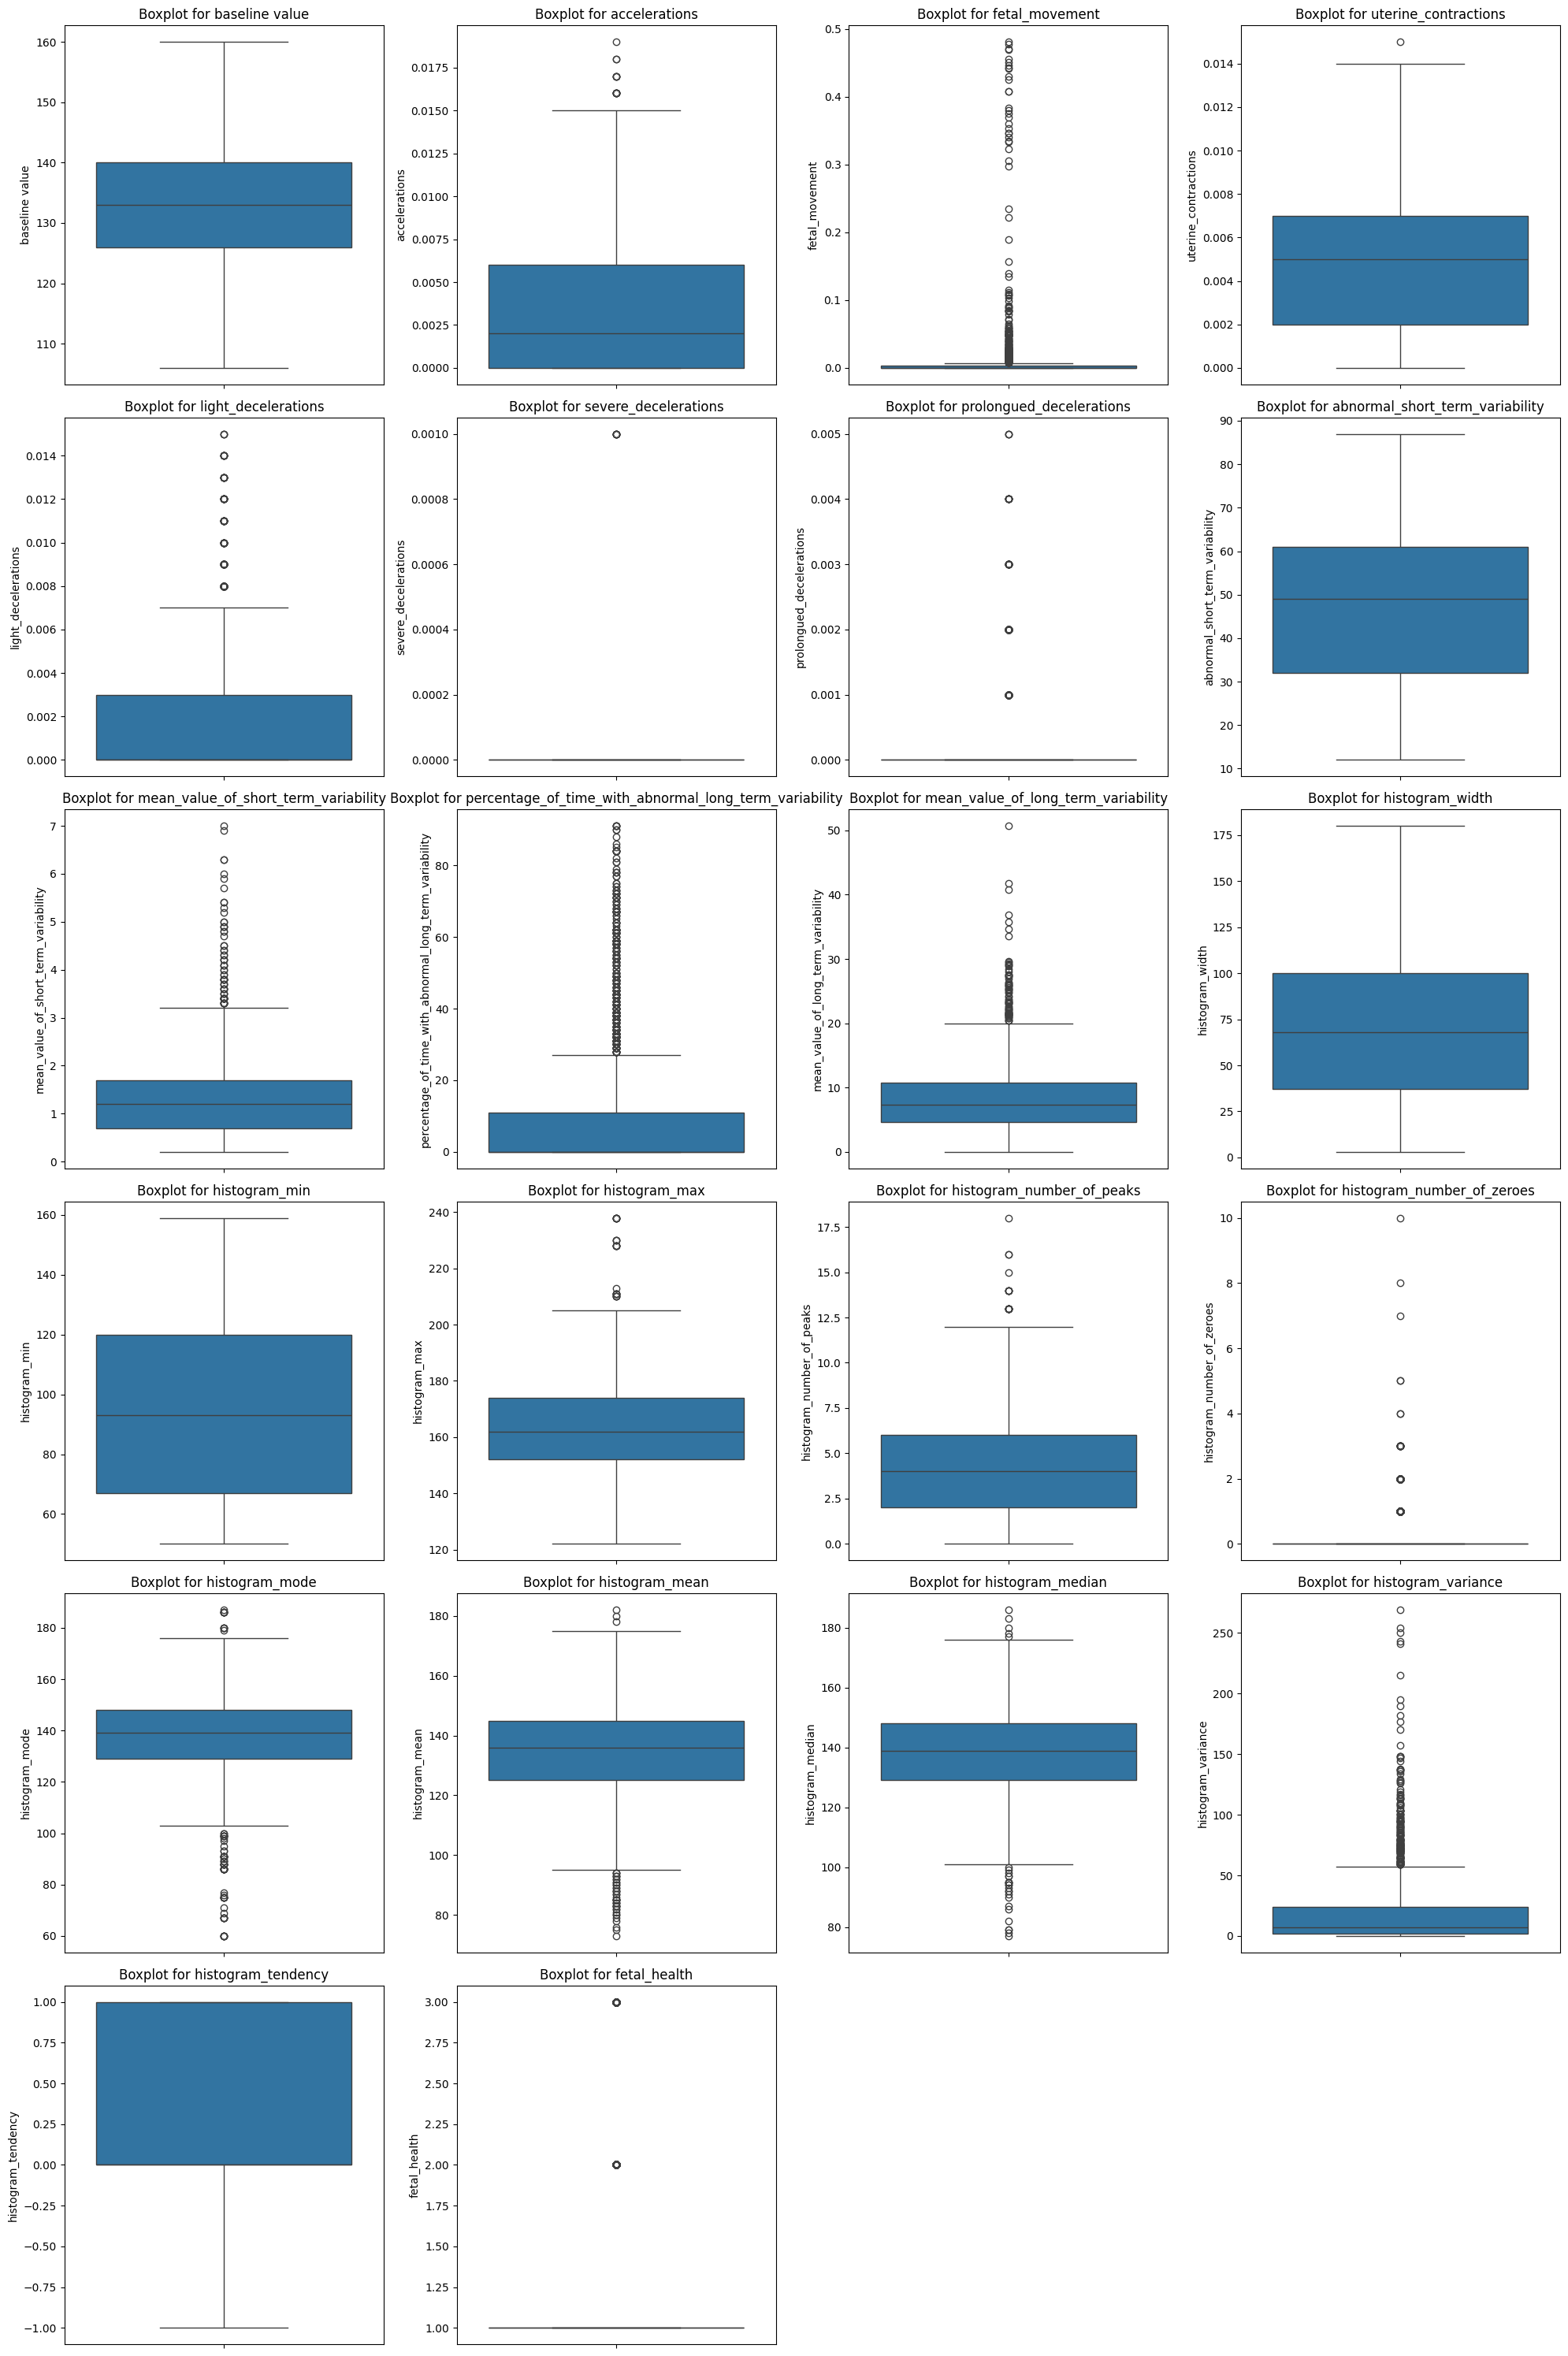

In [15]:
# Number of columns per row
cols_per_row = 4
num_vars = len(df.columns)
num_rows = math.ceil(num_vars / cols_per_row)
fig, axes = plt.subplots(nrows=num_rows, ncols=cols_per_row, figsize=(20, 5 * num_rows))

axes = axes.flatten()
# Loop through each column and create a boxplot
for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot for {col}")

# Hide any unused subplots
for i in range(num_vars, len(axes)):
    fig.delaxes(axes[i])


plt.tight_layout()
plt.show()

These variables contain outliers:

In [16]:
def find_outlier_columns(df, iqr_multiplier=1.5):
    outlier_vars = []

    for col in df.select_dtypes(include=np.number):  # Select only numerical columns
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR

        # Check if any value in the column is an outlier
        if ((df[col] < lower_bound) | (df[col] > upper_bound)).any():
            outlier_vars.append(col)

    print("Variables with outliers:", outlier_vars)
    return outlier_vars

outlier_vars = find_outlier_columns(df)

Variables with outliers: ['accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability', 'histogram_max', 'histogram_number_of_peaks', 'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean', 'histogram_median', 'histogram_variance', 'fetal_health']


 Apply LOF to find outliers using only the variables flagged:

In [17]:
def remove_outliers_lof(df, outlier_vars, contamination=0.10):
    df_outliers = df[outlier_vars].copy()

    # Normalize data
    df_outliers = (df_outliers - df_outliers.mean()) / df_outliers.std()

    # Apply LOF
    lof = LocalOutlierFactor(contamination=contamination)
    outlier_labels = lof.fit_predict(df_outliers)  # -1 = outlier, 1 = inlier

    # Add LOF scores and labels to the original DataFrame
    df = df.copy()
    df['LOF_Score'] = lof.negative_outlier_factor_
    df['LOF_Label'] = outlier_labels

    # Number of detected outliers
    num_outliers = (df['LOF_Label'] == -1).sum()
    print("Number of outliers detected by LOF:", num_outliers)

    # df without outliers
    df_no_outliers = df[df['LOF_Label'] != -1].drop(columns=['LOF_Label', 'LOF_Score'])

    return df_no_outliers


df_without_lof = remove_outliers_lof(df, outlier_vars, contamination=0.10)

Number of outliers detected by LOF: 212


Since LOF is used on multiple columns, the detected outlier means the whole row is an anomaly. We decided to delete those rows.

##### **Predictive analysis: Decision Trees**

Explore the DecisionTreeClassifier :

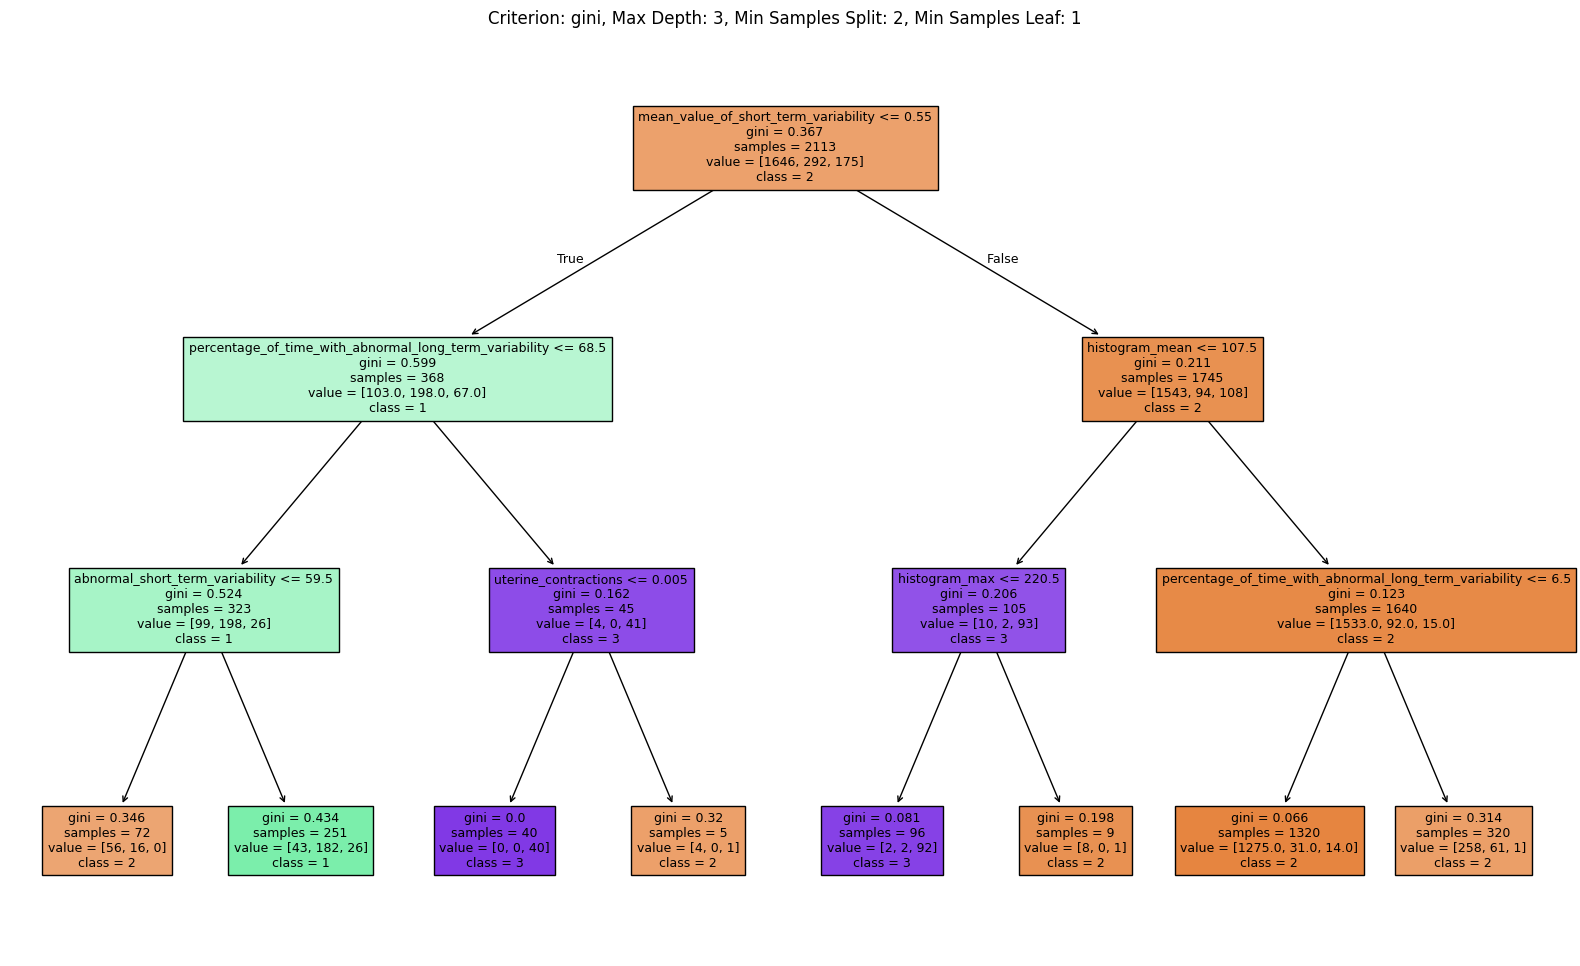

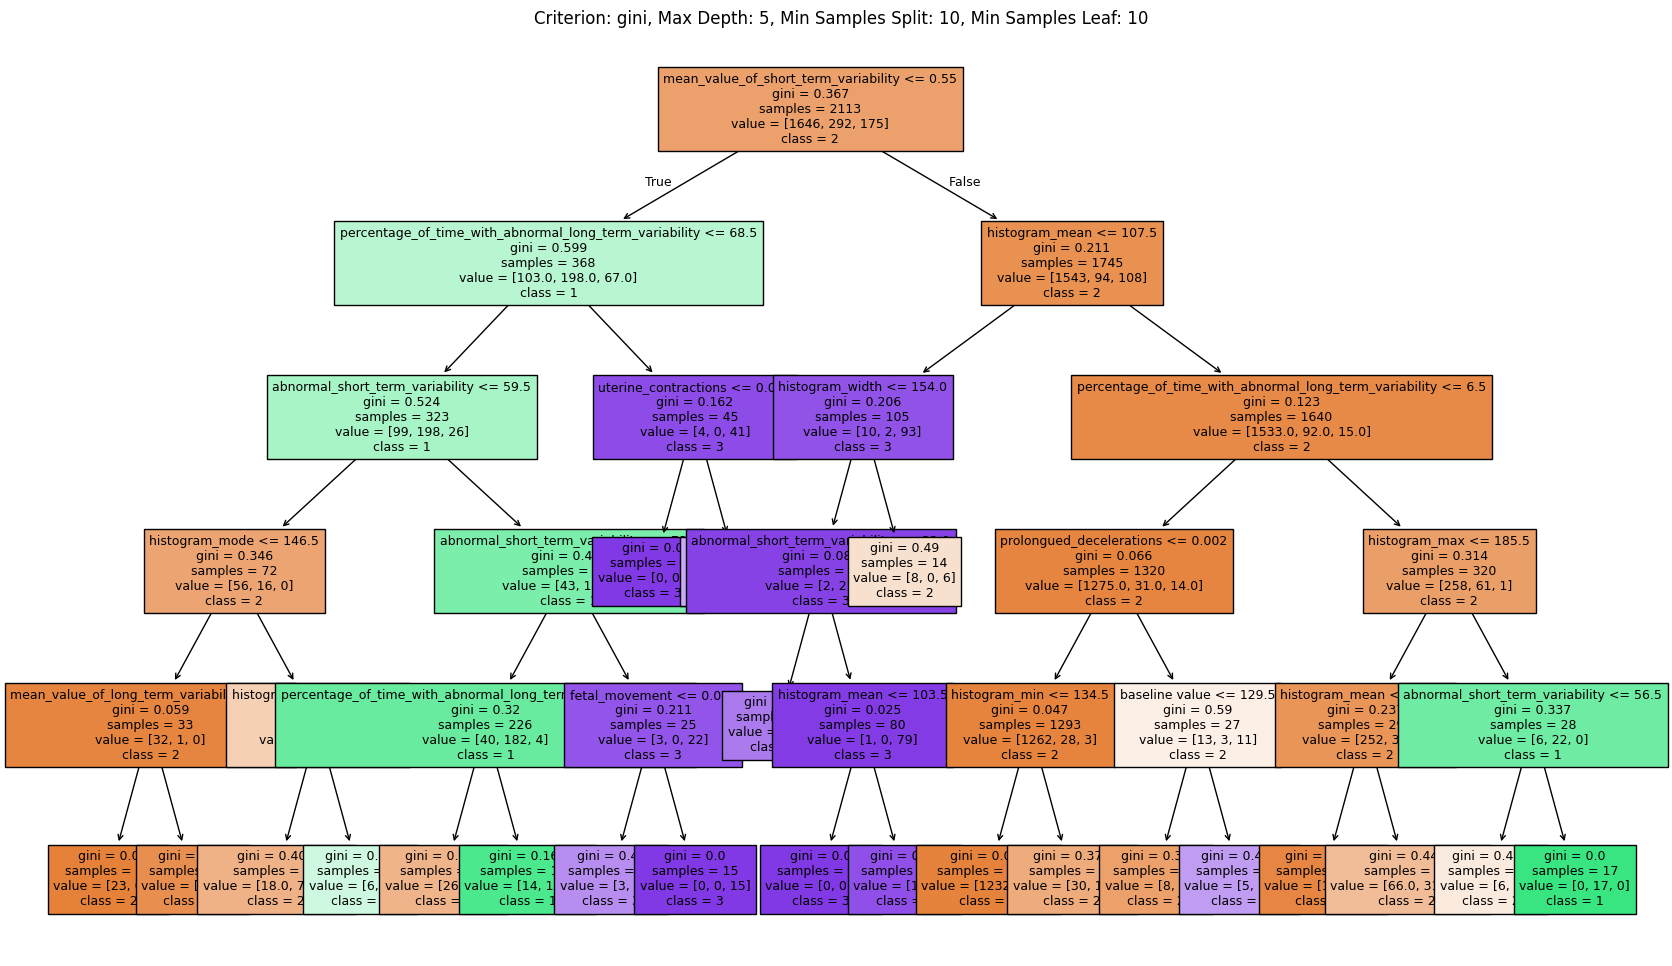

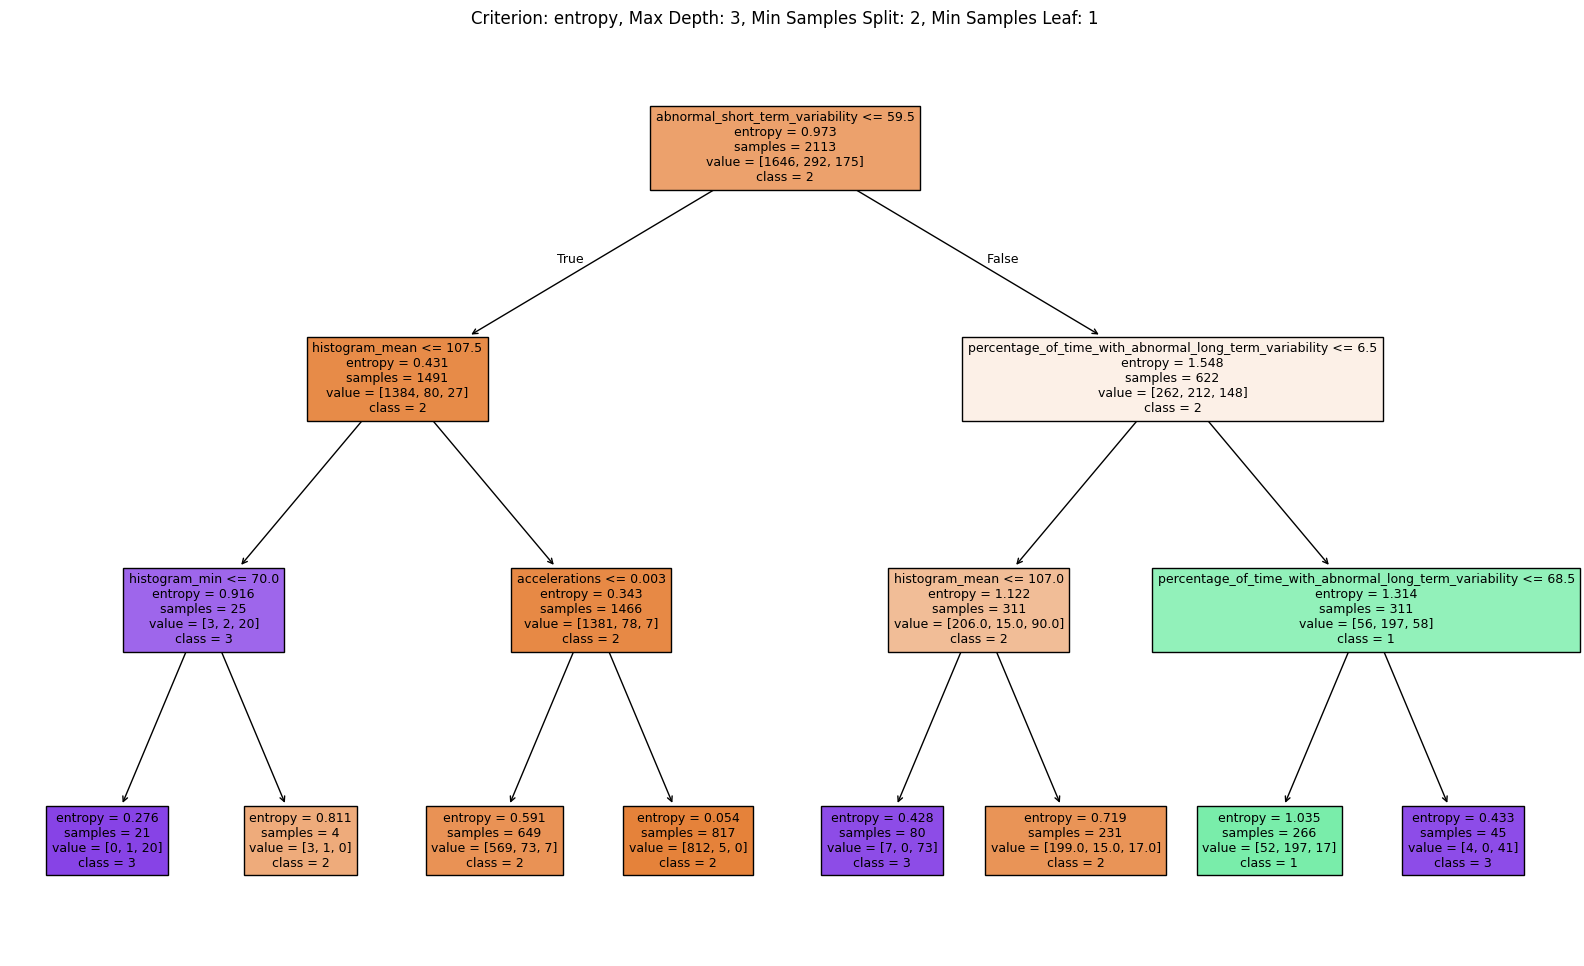

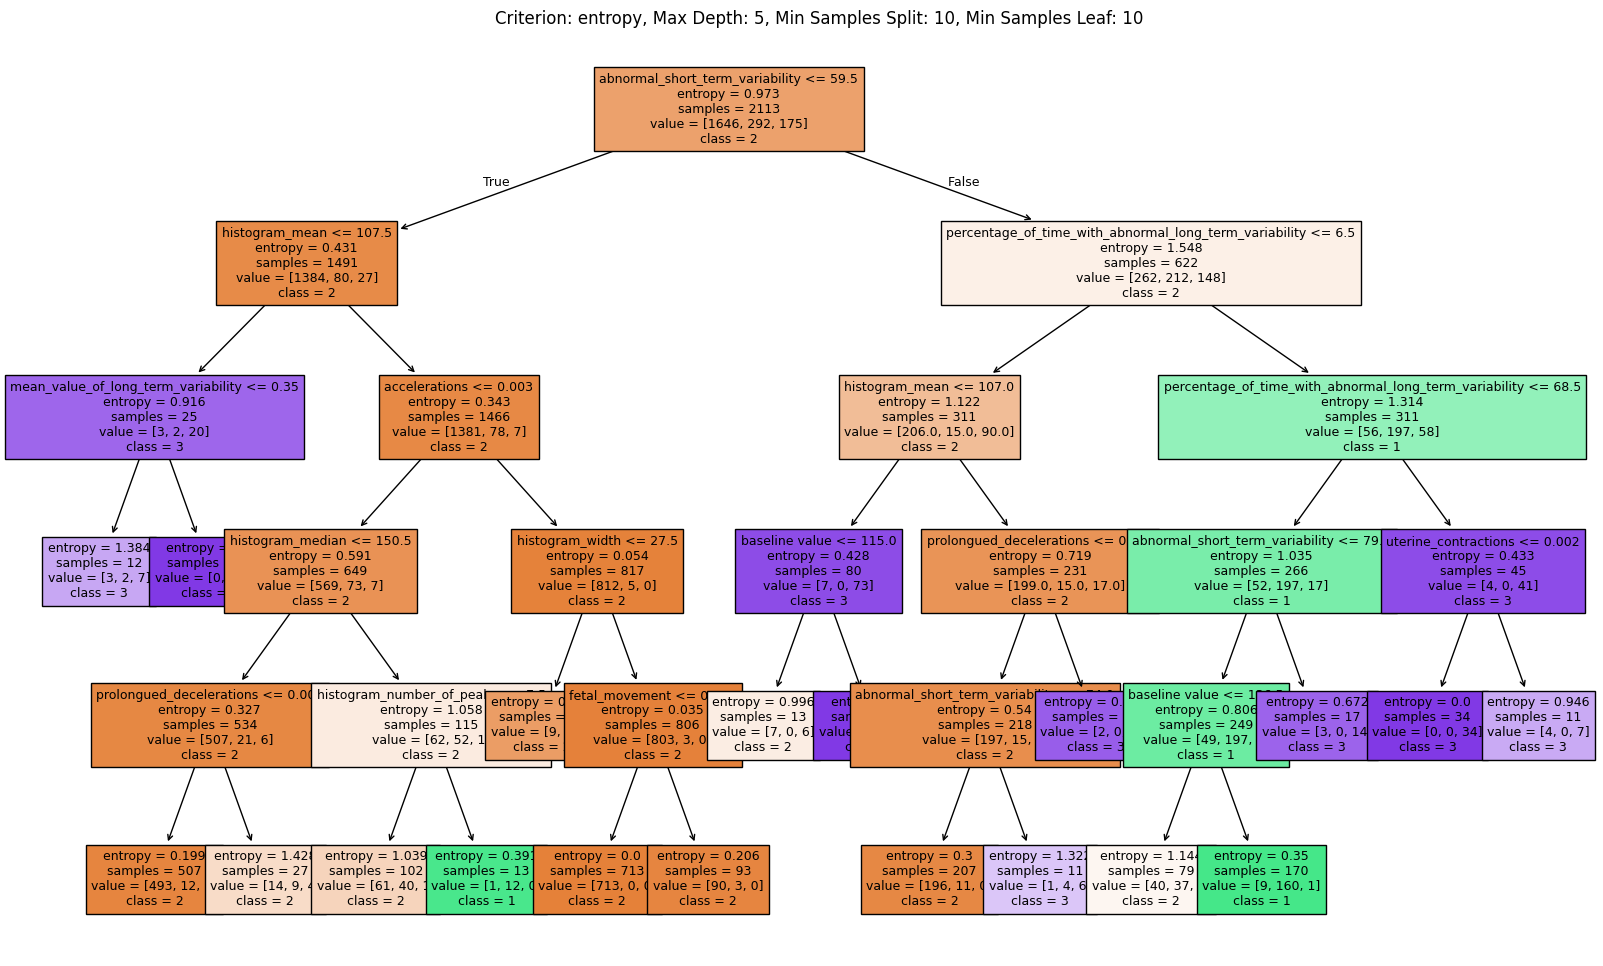

In [18]:
X, y = df.drop(columns=["fetal_health"]), df["fetal_health"]

# Feature and class names
feature_names = X.columns
class_names = y.unique().astype(str)

param_grid = [
    {"criterion": "gini", "max_depth": 3, "min_samples_split": 2, "min_samples_leaf": 1},
    {"criterion": "gini", "max_depth": 5, "min_samples_split": 10, "min_samples_leaf": 10},
    {"criterion": "entropy", "max_depth": 3, "min_samples_split": 2, "min_samples_leaf": 1},
    {"criterion": "entropy", "max_depth": 5, "min_samples_split": 10, "min_samples_leaf": 10},
]

# Iterate through different parameter combinations
for params in param_grid:
    clf = DecisionTreeClassifier(**params, random_state=42)
    clf.fit(X, y)

    # Create a large figure for readability
    plt.figure(figsize=(20, 12))
    plot_tree(clf, filled=True, feature_names=feature_names, class_names=class_names, fontsize = 9)
    plt.title(f"Criterion: {params['criterion']}, Max Depth: {params['max_depth']}, "
              f"Min Samples Split: {params['min_samples_split']}, Min Samples Leaf: {params['min_samples_leaf']}")
    plt.show()



In [19]:
clf_baseline = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_split=2, min_samples_leaf=1, random_state=42)

##### **Feature Engineering**

In [20]:
def feature_aggregation(df):
    df = df.copy()

    # Total decelerations
    df['total_decelerations'] = (
        df['light_decelerations'] + df['severe_decelerations'] + df['prolongued_decelerations']
    )

    # Mean of short-term and long-term variability
    df['mean_variability'] = (
        df['mean_value_of_short_term_variability'] + df['mean_value_of_long_term_variability']
    ) / 2

    # Standard deviation of short-term and long-term variability
    df['std_variability'] = df[['mean_value_of_short_term_variability', 'mean_value_of_long_term_variability']].std(axis=1)

    # Ratio of accelerations to fetal movements
    df['acceleration_to_movement'] = df['accelerations'].replace(0, 1e-6) / df['fetal_movement'].replace(0, 1e-6)

    return df

##### **Empirical study**

Split the Dataset:

In [21]:
X = df.drop('fetal_health', axis=1)
y = df['fetal_health']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

D_R = pd.concat([X_train, y_train], axis=1)
D_T = pd.concat([X_test, y_test], axis=1)

Generate 4 Variations of D_R:

In [22]:
D_R1 = D_R  # Original dataset
D_R2 = remove_outliers_lof(D_R, outlier_vars, contamination=0.10)  # Dataset with outliers removed
D_R3 = feature_aggregation(D_R)  # Dataset with feature aggregation
D_R4 = feature_aggregation(D_R2)  # Dataset with feature aggregation and outliers removed

Number of outliers detected by LOF: 169


Perform 4-Fold Cross-Validation on Each DR:

In [23]:
# Model selection
model = clf_baseline

# Cross-validation function
def perform_cross_validation(X, y, model, k=4):
    X = X.astype(np.float64)
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    return np.mean(cv_scores)

# Perform 4-fold cross-validation on each variation of D_R
results = {}
for idx, D in enumerate([D_R1, D_R2, D_R3, D_R4], 1):
    X_temp = D.drop('fetal_health', axis=1)
    y_temp = D['fetal_health']
    avg_score = perform_cross_validation(X_temp, y_temp, model)
    results[f'D_R{idx}'] = avg_score
    print(f'D_R{idx} Cross-Validation Score: {avg_score}')

best_preprocessing = max(results, key=results.get)
print(f'Best Preprocessing: {best_preprocessing} with score {results[best_preprocessing]}')

D_R1 Cross-Validation Score: 0.9076851758484309
D_R2 Cross-Validation Score: 0.925039715430308
D_R3 Cross-Validation Score: 0.9053197091414295
D_R4 Cross-Validation Score: 0.9243835474513055
Best Preprocessing: D_R2 with score 0.925039715430308


Final Training and Testing

In [24]:
# Retrain the model on the best dataset
X_best = D_R4.drop('fetal_health', axis=1)
y_best = D_R4['fetal_health']
model.fit(X_best, y_best)

# Test the model on the test set D_T
D_T = feature_aggregation(D_T)
X_test = D_T.drop('fetal_health', axis=1)
y_test = D_T['fetal_health']
y_pred = model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Final Model Accuracy: {accuracy}')

Final Model Accuracy: 0.9314420803782506


##### **Conclusion**



###### **Impact of Preprocessing Techniques on Model Performance**
1. Baseline Model (D_R1 - Original Dataset)

  - Cross-validation score: 0.9147
  - The model performed well without any modifications, but there was room for improvement.
2. Outlier Removal (D_R2 - Using LOF)

  - Cross-validation score: 0.9216 (Best-performing preprocessing step)
  - Removing outliers using the Local Outlier Factor (LOF) slightly improved performance, likely due to reducing noise and improving model generalizability.
  
3. Feature Aggregation (D_R3 - Without Outlier Removal)

  - Cross-validation score: 0.9147 (Same as the original dataset)
  - Creating aggregated features (e.g., total_decelerations, mean_variability) did not directly enhance model performance, possibly due to redundancy or lack of significant new information.

4. Combining Feature Aggregation and Outlier Removal (D_R4 - LOF + Aggregation)
  - Cross-validation score: 0.9209
  - This approach slightly underperformed compared to only removing outliers (D_R2). This suggests that feature aggregation did not add value beyond what outlier removal already provided.

###### **Key Takeaways**
- **Outlier Removal Had the Most Impact** \
  Removing outliers using LOF yielded the best cross-validation score (0.9216), showing that eliminating noise improved model learning.

- **Feature Aggregation Had Minimal Effect**  \
Aggregating features did not significantly enhance model performance, which suggests that the original features already captured most of the predictive information.

- **Final Model Performance**  \
After selecting D_R2 (outlier removal) as the best preprocessing approach, the final model was trained and tested, achieving an accuracy of 0.9319 on the test set.

- **Future Considerations**  \
  - **Exploring More Advanced Feature Engineering** \
  Testing additional transformations, interactions, or dimensionality reduction techniques could yield more predictive features.
  - **Using More Sophisticated Outlier Detection Methods** \
  Experimenting with different contamination rates in LOF or alternative methods (e.g., Isolation Forest) could refine outlier identification.
  - **Ensemble Methods for Better Performance** \
  Applying models like Random Forest or Gradient Boosting could further improve accuracy by capturing complex patterns.

Overall, this study highlights the importance of EDA and outlier detection in improving model performance. While feature aggregation did not contribute significantly, outlier removal proved to be the most impactful step, leading to a more accurate fetal health classification model.

##### **References**

- https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification?resource=download
- https://archive.ics.uci.edu/dataset/193/cardiotocography
- https://scikit-learn.org/stable/modules/cross_validation.html
- https://www.geeksforgeeks.org/ways-to-visualize-individual-decision-trees-in-a-random-forest/
